In [2]:
#Importing all the neccessary libraries

import sqlite3
import pandas as pd
import numpy as np
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfTransformer, TfidfVectorizer, CountVectorizer
import sklearn.metrics as metrics
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
from nltk.stem.porter import PorterStemmer
import string
from nltk.corpus import stopwords
from nltk.stem.wordnet import WordNetLemmatizer
#from gensim.models import Word2Vec, KeyedVectors
import pickle
import warnings
warnings.filterwarnings("ignore")
from sklearn import datasets, neighbors
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from collections import Counter
from matplotlib.colors import ListedColormap
#import scikitplot.metrics as sciplot
from sklearn.metrics import accuracy_score
import math
import nltk
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
filtered_data = pd.read_csv(r"C:\Users\DELL\Desktop\course_prac\NLP\Sentiment_Analysis Project\Reviews.csv")

In [4]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [5]:
filtered_data.shape

(568454, 10)

In [6]:
filtered_data = filtered_data.sample(frac = 0.1,random_state=1)

score ranges from 1 to 5

below 3 -- negative review
above 3 -- positive review
equal to 3 -- neutral review

What if i don't have scores in my dataset?
Based on text data: whether the text data is positive, negative or neutral
Key words from the text data:
How to identify positive, negative and neutral words from the text data?
positive words: good, excellent, nice, amazing, fantastic, love, great, satisfied, happy, wonderful -- in one dictionary
Negative words: bad, poor, terrible, awful, hate, worst, disappointed, unsatisfied, unhappy -- in another dictionary

There may be a chnance that some words may be present in both the dictionaries:
How to deal with this: we will give more priority to negative words than positive words

What is naother way to identify positive, negative and neutral words from the text data?
We can use some pre defined libraries in python:nltk -- natural language toolkit    

Input text data --- I can build any clustering algorithm(three clusters) to identify positive, negative and neutral words from the text data

I am very bad satsfied with the product -- he will give rating as 4    

Sarcasm -- he will give rating as 4 but the review is negative

example for sarcasm: The product is good but the service is bad    -- TATA cars --- 

With in the tool we need to identify the positive, negative and neutral , sarcasm words from the text data

In [7]:
filtered_data.shape

(56845, 10)

In [8]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
288312,288313,B000ENUC3S,AN66F3Q4QNU43,Donna Speaker,0,0,5,1340496000,Cherry Pie Larabar,I love the Cherry Pie Lara bar. Best and tast...
431726,431727,B002TMV3CG,A3G007LQX6KGOD,SevereWX,0,0,5,1287878400,Melitta Coffee,Melitta Cafe COllection Blanc et Noir coffee h...
110311,110312,B004867T24,A11LNY2OLQSUSV,M. Castillo,0,0,5,1331769600,great treat,my girls absolutely loved this tuna. they were...
91855,91856,B004U7KPY0,A1QCYVHWO5934U,"PistolaMia ""PistolaMia""",0,0,5,1332806400,Daily Calming,The vendor is fast and dependable. The tea is ...
338855,338856,B000FD78R0,A30U2QQN2FFHE9,J. Amicucci,2,3,5,1271376000,Best Canned Artichokes Out There!,UPDATE - 8/9/2010<br />A lot can happen in jus...


In [9]:
#Give reviews with Score > 3 a 'Positive' tag, and reviews with a score < 3 a 'Negative' tag.
filtered_data['SentimentPolarity'] = filtered_data['Score'].apply(lambda x : 'Positive' if x > 3 else ('Neutral'if x == 3 else 'Negative'))

In [10]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,SentimentPolarity
288312,288313,B000ENUC3S,AN66F3Q4QNU43,Donna Speaker,0,0,5,1340496000,Cherry Pie Larabar,I love the Cherry Pie Lara bar. Best and tast...,Positive
431726,431727,B002TMV3CG,A3G007LQX6KGOD,SevereWX,0,0,5,1287878400,Melitta Coffee,Melitta Cafe COllection Blanc et Noir coffee h...,Positive
110311,110312,B004867T24,A11LNY2OLQSUSV,M. Castillo,0,0,5,1331769600,great treat,my girls absolutely loved this tuna. they were...,Positive
91855,91856,B004U7KPY0,A1QCYVHWO5934U,"PistolaMia ""PistolaMia""",0,0,5,1332806400,Daily Calming,The vendor is fast and dependable. The tea is ...,Positive
338855,338856,B000FD78R0,A30U2QQN2FFHE9,J. Amicucci,2,3,5,1271376000,Best Canned Artichokes Out There!,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive


In [11]:
filtered_data['SentimentPolarity'].value_counts()

SentimentPolarity
Positive    44391
Negative     8163
Neutral      4291
Name: count, dtype: int64

In [12]:
filtered_data['Class_Labels'] = filtered_data['SentimentPolarity'].apply(lambda x : 2 if x == 'Positive' else (1 if x == 'Neutral' else 0))

In [13]:
filtered_data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,SentimentPolarity,Class_Labels
288312,288313,B000ENUC3S,AN66F3Q4QNU43,Donna Speaker,0,0,5,1340496000,Cherry Pie Larabar,I love the Cherry Pie Lara bar. Best and tast...,Positive,2
431726,431727,B002TMV3CG,A3G007LQX6KGOD,SevereWX,0,0,5,1287878400,Melitta Coffee,Melitta Cafe COllection Blanc et Noir coffee h...,Positive,2
110311,110312,B004867T24,A11LNY2OLQSUSV,M. Castillo,0,0,5,1331769600,great treat,my girls absolutely loved this tuna. they were...,Positive,2
91855,91856,B004U7KPY0,A1QCYVHWO5934U,"PistolaMia ""PistolaMia""",0,0,5,1332806400,Daily Calming,The vendor is fast and dependable. The tea is ...,Positive,2
338855,338856,B000FD78R0,A30U2QQN2FFHE9,J. Amicucci,2,3,5,1271376000,Best Canned Artichokes Out There!,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive,2


In [14]:
filtered_data['Class_Labels'].value_counts()

Class_Labels
2    44391
0     8163
1     4291
Name: count, dtype: int64

In [15]:
filtered_data.shape

(56845, 12)

In [16]:
print("The number of positive,negative and Neutral reviews before the removal of duplicate data.")
print(filtered_data["SentimentPolarity"].value_counts())

The number of positive,negative and Neutral reviews before the removal of duplicate data.
SentimentPolarity
Positive    44391
Negative     8163
Neutral      4291
Name: count, dtype: int64


In [17]:
#Removing duplicate entries based on past knowledge.
filtered_duplicates=filtered_data.drop_duplicates(subset={"UserId","ProfileName","Time","Text"}, keep='first', inplace=True)

In [18]:
print("The number of positive,negative and Neutral reviews after the removal of duplicate data.")
print(filtered_data["SentimentPolarity"].value_counts())

The number of positive,negative and Neutral reviews after the removal of duplicate data.
SentimentPolarity
Positive    40741
Negative     7518
Neutral      3932
Name: count, dtype: int64


In [19]:
#Removing the entries where HelpfulnessNumerator > HelpfulnessDenominator.
final_data=filtered_data[filtered_data.HelpfulnessNumerator <= filtered_data.HelpfulnessDenominator]

In [20]:
final_data["SentimentPolarity"].value_counts()

SentimentPolarity
Positive    40741
Negative     7518
Neutral      3932
Name: count, dtype: int64

#### In this code block :

1. I am creating a copy of the final_data dataset called 'sampled_dataset' by dropping the unwanted columns that we don't need for this problem.
2. Sorting the data according to time, such that the oldest reviews are displayed at the top and the latest reviews are displayed at the bottom.
3. Displaying information about the number of postive,negative and neutral reviews in the sampled dataset, using a Histogram.

In [21]:
#Dropping unwanted columns for now.
sampled_dataset=final_data.drop(labels=['Id','ProductId', 'UserId', 'Score', 'ProfileName','HelpfulnessNumerator', 'HelpfulnessDenominator','Summary'], axis=1)
print("The shape of the sampled dataset after dropping unwanted columns : ", sampled_dataset.shape)
sampled_dataset.head()

The shape of the sampled dataset after dropping unwanted columns :  (52191, 4)


,Time,Text,SentimentPolarity,Class_Labels
288312,1340496000,I love the Cherry Pie Lara bar. Best and tast...,Positive,2
431726,1287878400,Melitta Cafe COllection Blanc et Noir coffee h...,Positive,2
110311,1331769600,my girls absolutely loved this tuna. they were...,Positive,2
91855,1332806400,The vendor is fast and dependable. The tea is ...,Positive,2
338855,1271376000,UPDATE - 8/9/2010<br />A lot can happen in jus...,Positive,2


In [22]:
#Sorting data according to Time in ascending order => Time Based Splitting Step 1.
sampled_dataset=sampled_dataset.sort_values('Time', axis=0, ascending=False, inplace=False, kind='quicksort', na_position='last')

In [23]:
sampled_dataset = sampled_dataset.reset_index()

In [24]:
sampled_dataset.head()

,index,Time,Text,SentimentPolarity,Class_Labels
0,317935,1351209600,It is hard to find much of anything sugarfree ...,Positive,2
1,271217,1351209600,Shake the container and they come running. Eve...,Positive,2
2,381087,1351209600,If you like sponge candy- and have never tried...,Positive,2
3,180007,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,2
4,118928,1351209600,All my dogs love them. Healthy treats. Not gre...,Positive,2


In [25]:
sampled_dataset=sampled_dataset.drop(labels=['index'], axis=1)

In [26]:
sampled_dataset.head()

,Time,Text,SentimentPolarity,Class_Labels
0,1351209600,It is hard to find much of anything sugarfree ...,Positive,2
1,1351209600,Shake the container and they come running. Eve...,Positive,2
2,1351209600,If you like sponge candy- and have never tried...,Positive,2
3,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,2
4,1351209600,All my dogs love them. Healthy treats. Not gre...,Positive,2


<Axes: title={'center': 'Distribution Of Positive,Negative and Neutral reviews after De-Duplication.'}, xlabel='SentimentPolarity'>

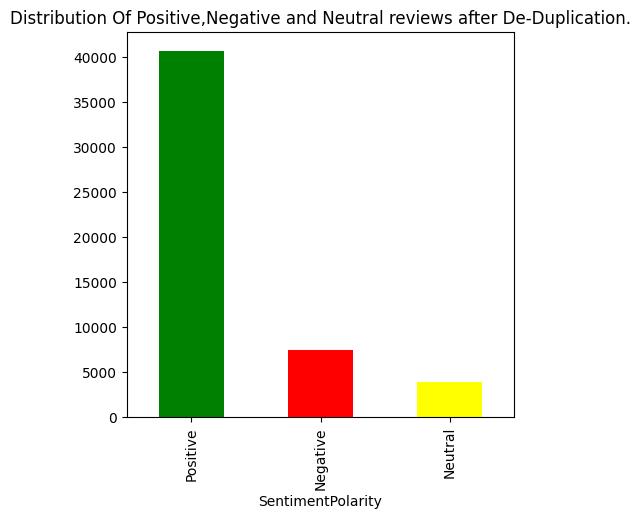

In [27]:
#Display distribution of Postive and Negative reviews in a bar graph
sampled_dataset["SentimentPolarity"].value_counts().plot(kind='bar',color=['green','red','yellow'],title='Distribution Of Positive,Negative and Neutral reviews after De-Duplication.',figsize=(5,5))

#### In this code block :

1. We define two functions which will remove the HTML tags and punctuations from each review.
2. At the end of this code block, each review will contain texts which will only contain alphabetical strings. 
3. We will apply techniques such as stemming and stopwords removal.
3. We will create two columns in the sampled dataset - 'CleanedText' and 'RemovedHTML'.
4. 'CleanedText' column will basically contain the data corpus after stemming the each reviews and removing stopwords from each review. We will use this for our Bag of Word model.
5. 'RemovedHTML' column will contain the data corpus from which only the HTML tags and punctuations are removed. We will use this column for our TF-IDF model, Average Word2Vec model and TF-IDF weighted average Word2Vec model.
6. Store the final table in a dataset called 'sampled_dataset' for future use.

In [28]:
import re

review = "i am satisfied with the product , and the service is good... @  ! 7 % $ and the delivery is on time <br /> <br /> overall i am happy with the product.product"

def RemoveHtml(sentence):
  pattern = re.compile('<.*?>')
  cleaned_text = re.sub(pattern,' ',sentence)
  return cleaned_text

In [29]:
cleaned_review=RemoveHtml(review)
print("The review after removing html tags : ",cleaned_review)

The review after removing html tags :  i am satisfied with the product , and the service is good... @  ! 7 % $ and the delivery is on time     overall i am happy with the product.product


In [30]:
#Function to keep only words containing letters A-Z and a-z. This will remove all punctuations, special characters etc.
def removePunctuations(sentence):
    cleaned_text  = re.sub('[^a-zA-Z]',' ',sentence)
    return cleaned_text

In [31]:
cleaned_review_only_text = removePunctuations(cleaned_review)
print("The review after removing  Punctuations : ",cleaned_review_only_text)

The review after removing  Punctuations :  i am satisfied with the product   and the service is good               and the delivery is on time     overall i am happy with the product product


In [32]:
# ineed to strip the text data and convert it into lower case
#Function to convert the entire sentence to lower case and strip the extra spaces.  
def stripLower(sentence):
    cleaned_text = sentence.lower().strip()
    cleaned_text = re.sub(' +', ' ', cleaned_text)
    return cleaned_text

In [33]:
final_cleaned_review = stripLower(cleaned_review_only_text)
print("The review after converting to lower case and stripping extra spaces : ",final_cleaned_review)

The review after converting to lower case and stripping extra spaces :  i am satisfied with the product and the service is good and the delivery is on time overall i am happy with the product product


In [34]:
final_cleaned_review

'i am satisfied with the product and the service is good and the delivery is on time overall i am happy with the product product'

In [35]:
def take_only_distinct_words(sentence):
  word_tokens = sentence.split()
  seen = set()
  cleaned_text = []
  for word in word_tokens:
    if word not in seen:
      cleaned_text.append(word)
      seen.add(word)
  cleaned_text = ' '.join(cleaned_text)
  return cleaned_text

cleaned_review_distinct_words = take_only_distinct_words(final_cleaned_review)
print("The review after taking only distinct words : ", cleaned_review_distinct_words)

The review after taking only distinct words :  i am satisfied with the product and service is good delivery on time overall happy


In [36]:
import nltk   #spacy
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [38]:
# my next step is to remove stop words from the text data

nltk.download('stopwords')
def removeStopWords(sentence):
  stop_words = set(stopwords.words('english'))
   # need to take all negative words from the stop words in list after that we will remove those words from the stop words
    #print("The stop words are : ", stop_words)
  negative_words = ["not", "no", "nor", "never", "don't", "didn't", "doesn't", "isn't", "wasn't", "shouldn't", "wouldn't", "couldn't", "won't", "haven't", "hasn't", "hadn't", "mightn't", "mustn't", "shan't"]
    #print("The negative words are : ", negative_words)
  stop_words = stop_words - set(negative_words)
  word_tokens = sentence.split()
  cleaned_text = [word for word in word_tokens if not word in stop_words]
  cleaned_text = ' '.join(cleaned_text)
  return cleaned_text

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
rev_after_stopwords = removeStopWords(cleaned_review_distinct_words)

In [40]:
rev_test = "satisfy  satisfied  satisfied satisfaction satisfactory satisfyingly"
# next step is to use stemming or  lemmatisation on the text data:
from nltk.stem.porter import PorterStemmer
def stemming(sentence):
    porter_stemmer = PorterStemmer()
    word_tokens = sentence.split()
    cleaned_text = [porter_stemmer.stem(word) for word in word_tokens]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text

In [41]:
review_after_stemming = stemming(rev_test)
print("The review after stemming : ",review_after_stemming)

The review after stemming :  satisfi satisfi satisfi satisfact satisfactori satisfyingli


In [42]:
# create a function to use the stemming technique with snowball stemmer
def stemming_with_snowball(sentence):
    from nltk.stem.snowball import SnowballStemmer
    snowball_stemmer = SnowballStemmer(language='english')
    word_tokens = sentence.split()
    cleaned_text = [snowball_stemmer.stem(word) for word in word_tokens]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text

In [43]:
review_after_snowball_stemming = stemming_with_snowball(rev_test)
print("The review after snowball stemmer : ",review_after_snowball_stemming)

The review after snowball stemmer :  satisfi satisfi satisfi satisfact satisfactori satisfi


Stemming Vs Lemmatisation Explanation:
Stemming and lemmatization are both techniques used in natural language processing (NLP) to reduce words to their base or root form, but they do so in different ways and with different levels of accuracy.
Stemming:
Stemming is a crude heuristic process that chops off the ends of words in the hope of achieving the correct base form of the word. It often involves removing common prefixes or suffixes. Stemming algorithms, such as the Porter Stemmer or Snowball Stemmer, use simple rules to perform this task.
Lemmatisation:
Lemmatisation, on the other hand, is a more sophisticated process that considers the context and the morphological analysis of words. It involves using a vocabulary and morphological analysis of words to return the base or dictionary form of a word, known as the lemma. Lemmatisation takes into account the part of speech and the meaning of the word, which often results in more accurate base forms. For example, the lemma of "better" is "good," and the lemma of "running" is "run."
Lemmatisation typically requires more computational resources and is slower than stemming due to its complexity and reliance on linguistic knowledge.


Stemming is faster and more efficient, while lemmatization is more accurate and context-aware. The choice between the two depends on the specific requirements of the NLP task at hand.

In [44]:
def lemmatization(sentence):
    lemmatizer = WordNetLemmatizer()
    word_tokens = sentence.split()
    cleaned_text = [lemmatizer.lemmatize(word) for word in word_tokens]
    cleaned_text = ' '.join(cleaned_text)
    return cleaned_text

review_after_lemmatization = lemmatization(rev_test)
print("The review after lemmatization : ",review_after_lemmatization)

The review after lemmatization :  satisfy satisfied satisfied satisfaction satisfactory satisfyingly


In [45]:
sampled_dataset.head(2)

,Time,Text,SentimentPolarity,Class_Labels
0,1351209600,It is hard to find much of anything sugarfree ...,Positive,2
1,1351209600,Shake the container and they come running. Eve...,Positive,2


In [46]:
def data_preprocessing(sentence):
  sentence = RemoveHtml(sentence)
  sentence = removePunctuations(sentence)
  sentence = stripLower(sentence)
  sentence = take_only_distinct_words(sentence)
  sentence = removeStopWords(sentence)
  sentence = stemming(sentence)
  return sentence

# we will call this function for each and every review in our dataset
sampled_dataset['Cleaned_text'] = sampled_dataset['Text'].apply(data_preprocessing)

In [47]:
sampled_dataset.head()

,Time,Text,SentimentPolarity,Class_Labels,Cleaned_text
0,1351209600,It is hard to find much of anything sugarfree ...,Positive,2,hard find much anyth sugarfre realli tast good...
1,1351209600,Shake the container and they come running. Eve...,Positive,2,shake contain come run even boy cat big food l...
2,1351209600,If you like sponge candy- and have never tried...,Positive,2,like spong candi never tri realli miss not abl...
3,1351209600,"Every month, we give our three dogs (two Aussi...",Positive,2,everi month give three dog two aussi golden fl...
4,1351209600,All my dogs love them. Healthy treats. Not gre...,Positive,2,dog love healthi treat not great train crumbl ...


In [48]:
sampled_dataset = sampled_dataset[['Time','Cleaned_text','Class_Labels']]

In [49]:
print(sampled_dataset.shape)
sampled_dataset.head()

(52191, 3)


,Time,Cleaned_text,Class_Labels
0,1351209600,hard find much anyth sugarfre realli tast good...,2
1,1351209600,shake contain come run even boy cat big food l...,2
2,1351209600,like spong candi never tri realli miss not abl...,2
3,1351209600,everi month give three dog two aussi golden fl...,2
4,1351209600,dog love healthi treat not great train crumbl ...,2


In [50]:
sampled_dataset['Class_Labels'].value_counts()

Class_Labels
2    40741
0     7518
1     3932
Name: count, dtype: int64

In [51]:
#Split the data set into train and test sets. The test set should be unseen. Time Based Splitting Step 2.
#The top old 80% data will get into the train set. The latest 20% data will get into the test set.
def splitting_data(data):
    X = data['Cleaned_text']
    y = data['Class_Labels']
    return X,y

In [52]:
X,y = splitting_data(sampled_dataset)

In [53]:
X

0        hard find much anyth sugarfre realli tast good...
1        shake contain come run even boy cat big food l...
2        like spong candi never tri realli miss not abl...
3        everi month give three dog two aussi golden fl...
4        dog love healthi treat not great train crumbl ...
                               ...                        
52186    beetlejuic not movi watch time one funiest mov...
52187    set small new england town tim burton masterpi...
52188    michael keaton alreadi way major star play gho...
52189    beetlejuic awe inspir wonder amus comed romp e...
52190    twist rumplestiskin captur film star michael k...
Name: Cleaned_text, Length: 52191, dtype: object

In [54]:
y

0        2
1        2
2        2
3        2
4        2
        ..
52186    2
52187    2
52188    2
52189    2
52190    2
Name: Class_Labels, Length: 52191, dtype: int64

In [55]:
split = math.floor(0.8*len(X))
print("split value is :",split)

X_train = X[0:split,] ; y_train = y[0:split,]

X_test = X[split:,] ; y_test = y[split:,]

split value is : 41752


In [56]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(41752,)
(10439,)
(41752,)
(10439,)


In [57]:
X_train

0        hard find much anyth sugarfre realli tast good...
1        shake contain come run even boy cat big food l...
2        like spong candi never tri realli miss not abl...
3        everi month give three dog two aussi golden fl...
4        dog love healthi treat not great train crumbl ...
                               ...                        
41747    notic quit peopl seem believ label product mad...
41748    avid tea drinker drink lot green everi day gre...
41749               order liter ate day pack addict delici
41750    displeas amazon descript say raw realiti label...
41751    pro gevalia say dark chocol mean con sinc oz b...
Name: Cleaned_text, Length: 41752, dtype: object

In [58]:
X_test

41752    good earth restaur tea addict continu onlin pu...
41753    buy chai world market stop sell tri mani brand...
41754    nice light simpl yet flavor dress receiv compl...
41755    son not eat wheat dairi make food gf df great ...
41756    bj brewhous start serv douw egbert coffe year ...
                               ...                        
52186    beetlejuic not movi watch time one funiest mov...
52187    set small new england town tim burton masterpi...
52188    michael keaton alreadi way major star play gho...
52189    beetlejuic awe inspir wonder amus comed romp e...
52190    twist rumplestiskin captur film star michael k...
Name: Cleaned_text, Length: 10439, dtype: object

In [59]:
y_train

0        2
1        2
2        2
3        2
4        2
        ..
41747    2
41748    2
41749    2
41750    0
41751    2
Name: Class_Labels, Length: 41752, dtype: int64

In [60]:
y_test

41752    2
41753    2
41754    2
41755    2
41756    2
        ..
52186    2
52187    2
52188    2
52189    2
52190    2
Name: Class_Labels, Length: 10439, dtype: int64

In [61]:
def total_unique_words(corpus):
  vectorizer = CountVectorizer()
  X = vectorizer.fit_transform(corpus)
  unique_words = vectorizer.get_feature_names_out()
  return unique_words,len(unique_words)


In [62]:
# Calculate total unique words in X_train
unique_words, num_unique_words = total_unique_words(X_train)
print("Total unique words:", num_unique_words)
print("Sample unique words:", unique_words[:20])

Total unique words: 25399
Sample unique words: ['aa' 'aaa' 'aaaa' 'aaaaa' 'aaaaaaaaaaaaaaaaaaaargh' 'aaaaaah' 'aaaaallll'
 'aaaahhhhhh' 'aaah' 'aabsolut' 'aacut' 'aafco' 'aah' 'aakaufman'
 'aalmost' 'aamazon' 'aap' 'aargh' 'aaround' 'aarti']


# 📚 Bag of Words (BoW) vs TF-IDF

Machine Learning models cannot understand text directly. Therefore, text data must be converted into numerical vectors before training.

The two most common techniques are:

- **Bag of Words (BoW)**
- **TF-IDF (Term Frequency - Inverse Document Frequency)**

---

# Example Sentences

```python
sentence1 = "I love programming in Python"
sentence2 = "Python is a great programming language"
sentence3 = "I enjoy solving problems with Python"
```

---

# 1. Bag of Words (BoW)

## Definition

Bag of Words converts text into numerical vectors by counting the frequency of each word in a document.

It ignores:

- Word order
- Grammar
- Context

---

## Step 1: Create Vocabulary

Collect all unique words.

| Index | Word |
|------:|------|
|1|I|
|2|love|
|3|programming|
|4|in|
|5|Python|
|6|is|
|7|a|
|8|great|
|9|language|
|10|enjoy|
|11|solving|
|12|problems|
|13|with|

Vocabulary Size = **13**

---

## Step 2: Create BoW Vectors

Count how many times each vocabulary word appears in **that sentence**.

| Sentence | BoW Vector |
|----------|------------|
| I love programming in Python | `[1,1,1,1,1,0,0,0,0,0,0,0,0]` |
| Python is a great programming language | `[0,0,1,0,1,1,1,1,1,0,0,0,0]` |
| I enjoy solving problems with Python | `[1,0,0,0,1,0,0,0,0,1,1,1,1]` |

---

## Advantages

- Simple
- Fast
- Easy to understand

---

## Disadvantages

- Ignores word importance
- Ignores context
- Produces sparse vectors
- Common words receive high importance

---

# 2. TF-IDF

## Definition

TF-IDF improves Bag of Words by assigning:

- Higher weight to important words
- Lower weight to common words

Example:

The word **Python** appears in every sentence.

Therefore it is less useful for distinguishing documents, so TF-IDF assigns it a lower score.

---

## Step 1: Term Frequency (TF)

Measures how often a word appears in a document.

### Formula

```text
TF =
(Number of times word appears in document)
------------------------------------------
Total words in document
```

Example

Sentence:

```text
I love programming in Python
```

Total words = **5**

TF(Python)

```text
1/5 = 0.20
```

---

## Step 2: Inverse Document Frequency (IDF)

Measures how rare or common a word is across all documents.

### Formula

```text
IDF =
log(
Total Documents
---------------
Documents containing the word
)
```

Examples

| Word | Appears In | IDF |
|------|------------|------|
| Python | 3 | log(3/3)=0 |
| Programming | 2 | log(3/2)=0.405 |
| Love | 1 | log(3/1)=1.098 |

Observation:

- Frequently occurring words → Low IDF
- Rare words → High IDF

---

## Step 3: TF-IDF

### Formula

```text
TF-IDF = TF × IDF
```

Example

Sentence:

```text
I love programming in Python
```

| Word | TF | IDF | TF-IDF |
|------|----|------|---------|
| Python |0.20|0|0|
| Programming|0.20|0.405|0.081|
| Love|0.20|1.098|0.220|

---

## Why does Python get 0?

Because it appears in **every document**.

```
IDF(Python)

= log(3/3)

= 0
```

Therefore

```
TF-IDF

= TF × IDF

= 0.20 × 0

= 0
```

Python is common, so it provides little information for distinguishing documents.

---

## Advantages

- Considers word importance
- Reduces weight of common words
- Better for text classification
- Produces better features than BoW

---

## Disadvantages

- Ignores word order
- Ignores context
- Cannot capture semantics

---

# CountVectorizer vs TfidfVectorizer

| CountVectorizer | TfidfVectorizer |
|-----------------|-----------------|
| Uses Bag of Words | Uses TF-IDF |
| Counts word frequency | Computes TF × IDF |
| Common words get high weight | Common words get low weight |
| Simple | More informative |
| Faster | Slightly slower |

---

# Python Implementation

## Bag of Words

```python
from sklearn.feature_extraction.text import CountVectorizer

sentences = [sentence1, sentence2, sentence3]

cv = CountVectorizer()

X = cv.fit_transform(sentences)

print(cv.get_feature_names_out())
print(X.toarray())
```

---

## TF-IDF

```python
from sklearn.feature_extraction.text import TfidfVectorizer

sentences = [sentence1, sentence2, sentence3]

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(sentences)

print(tfidf.get_feature_names_out())
print(X.toarray())
```

---

# BoW vs TF-IDF

| Feature | BoW | TF-IDF |
|----------|-----|---------|
| Uses word frequency | ✅ | ✅ |
| Considers word importance | ❌ | ✅ |
| Common words get high weight | ✅ | ❌ |
| Better for NLP | ❌ | ✅ |
| Easy to understand | ✅ | Moderate |

---

# When to Use

### Bag of Words

- Small datasets
- Learning NLP
- Simple text classification

### TF-IDF

- Sentiment Analysis
- Spam Detection
- Review Classification
- Document Classification

---

# Interview Questions

### Why is TF-IDF better than Bag of Words?

**Answer**

Bag of Words only counts frequencies, so common words may dominate the feature representation. TF-IDF reduces the importance of common words and increases the importance of rare, informative words, making it more effective for most NLP classification tasks.

---

### Which vectorizer is generally preferred?

**Answer**

TF-IDF is generally preferred because it captures both term frequency and word importance, leading to better performance in most text classification problems.

In [63]:
def text_to_bow(corpus):
  cv_object = CountVectorizer()
  X_bow = cv_object.fit_transform(corpus)

  with open('Count_Vectorizer.pkl','wb') as f:
    pickle.dump(cv_object,f)
  return X_bow,cv_object
X_bow,cv_object = text_to_bow(X_train)

In [64]:
X_bow_array = X_bow.toarray()

In [65]:
X_bow.shape

(41752, 25399)

In [66]:
X_train

0        hard find much anyth sugarfre realli tast good...
1        shake contain come run even boy cat big food l...
2        like spong candi never tri realli miss not abl...
3        everi month give three dog two aussi golden fl...
4        dog love healthi treat not great train crumbl ...
                               ...                        
41747    notic quit peopl seem believ label product mad...
41748    avid tea drinker drink lot green everi day gre...
41749               order liter ate day pack addict delici
41750    displeas amazon descript say raw realiti label...
41751    pro gevalia say dark chocol mean con sinc oz b...
Name: Cleaned_text, Length: 41752, dtype: object

In [67]:
model = MultinomialNB()

In [68]:
# Train the model using the training sets
model.fit(X_bow,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [69]:
#Predict the response for test dataset
y_train_pred = model.predict(X_bow)

In [70]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_train, y_train_pred))

Accuracy: 0.8618748802452577


In [71]:
cm = confusion_matrix(y_train,y_train_pred)
print("confusion matrix:\n",cm)

confusion matrix:
 [[ 4311   103  1983]
 [  531   754  1956]
 [  899   295 30920]]


In [72]:
# classification report
from sklearn.metrics import classification_report
print("Classification Report on train data:\n", classification_report(y_train, y_train_pred))

Classification Report on train data:
               precision    recall  f1-score   support

           0       0.75      0.67      0.71      6397
           1       0.65      0.23      0.34      3241
           2       0.89      0.96      0.92     32114

    accuracy                           0.86     41752
   macro avg       0.76      0.62      0.66     41752
weighted avg       0.85      0.86      0.85     41752



In [73]:
# we need to convert the text data into numerical data by using saved count vectorizer object
# loading the count vectorizer object from pickle file
#Create a function to convert text data into numerical data using Bag of words for test data conversion
def text_to_bow_test(corpus):
    with open('count_vectorizer.pkl', 'rb') as f:
        loaded_cv_object = pickle.load(f)
    X_bow = loaded_cv_object.transform(corpus)
    return X_bow

X_test_bow = text_to_bow_test(X_test)

In [74]:

y_test_pred = model.predict(X_test_bow)

In [75]:
# classiffication report
print("Classification Report on test data:\n", classification_report(y_test, y_test_pred))

Classification Report on test data:
               precision    recall  f1-score   support

           0       0.62      0.51      0.56      1121
           1       0.31      0.06      0.10       691
           2       0.89      0.97      0.92      8627

    accuracy                           0.86     10439
   macro avg       0.61      0.51      0.53     10439
weighted avg       0.82      0.86      0.83     10439



In [76]:
# now we need to try with decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_bow, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [77]:
y_train_pred_dt = dt_model.predict(X_bow)
y_test_pred_dt = dt_model.predict(X_test_bow)
print("Classification Report on train data using Decision Tree Classifier:\n", classification_report(y_train,y_train_pred_dt))
print("Classification Report on test data using Decision Tree Classifier:\n", classification_report(y_test,y_test_pred_dt))

Classification Report on train data using Decision Tree Classifier:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6397
           1       1.00      1.00      1.00      3241
           2       1.00      1.00      1.00     32114

    accuracy                           1.00     41752
   macro avg       1.00      1.00      1.00     41752
weighted avg       1.00      1.00      1.00     41752

Classification Report on test data using Decision Tree Classifier:
               precision    recall  f1-score   support

           0       0.36      0.40      0.38      1121
           1       0.14      0.11      0.12       691
           2       0.88      0.89      0.88      8627

    accuracy                           0.78     10439
   macro avg       0.46      0.46      0.46     10439
weighted avg       0.78      0.78      0.78     10439



In [78]:
# now we will try on Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_bow, y_train)
y_train_pred_rf = rf_model.predict(X_bow)
y_test_pred_rf = rf_model.predict(X_test_bow)   
print("Classification Report on train data using Random Forest Classifier:\n", classification_report(y_train,y_train_pred_rf))
print("Classification Report on test data using Random Forest Classifier:\n", classification_report(y_test,y_test_pred_rf))

Classification Report on train data using Random Forest Classifier:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6397
           1       1.00      1.00      1.00      3241
           2       1.00      1.00      1.00     32114

    accuracy                           1.00     41752
   macro avg       1.00      1.00      1.00     41752
weighted avg       1.00      1.00      1.00     41752

Classification Report on test data using Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.85      0.16      0.27      1121
           1       1.00      0.00      0.00       691
           2       0.84      1.00      0.91      8627

    accuracy                           0.84     10439
   macro avg       0.90      0.39      0.40     10439
weighted avg       0.85      0.84      0.78     10439



In [79]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_bow,y_train)
y_train_pred_xgb = xgb_model.predict(X_bow)
y_test_pred_xgb = xgb_model.predict(X_test_bow)
print("Classification Report on train data using Random Forest Classifier:\n", classification_report(y_train,y_train_pred_xgb))
print("Classification Report on test data using Random Forest Classifier:\n", classification_report(y_test,y_test_pred_xgb))

Classification Report on train data using Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.88      0.64      0.74      6397
           1       0.93      0.31      0.47      3241
           2       0.89      0.99      0.94     32114

    accuracy                           0.89     41752
   macro avg       0.90      0.65      0.72     41752
weighted avg       0.89      0.89      0.87     41752

Classification Report on test data using Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.68      0.41      0.51      1121
           1       0.52      0.07      0.12       691
           2       0.88      0.98      0.93      8627

    accuracy                           0.86     10439
   macro avg       0.69      0.49      0.52     10439
weighted avg       0.83      0.86      0.83     10439



In [ ]:
# We need to do Hyperparameter tuning for all the models to improve the accuracy and other metrics
# We need to do cross validation for all the models to improve the accuracy and other metrics
# first we will do hyperparameter tuning for Random Forest Classifier

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced'],
    'criterion': ['gini', 'entropy']
}

#comb1 -- 50, None, 2, 1, auto, True,None, gini
#comb2 -- 50, None, 2, 1, auto, True,None, entropy

rf_model = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_bow, y_train)


In [ ]:
#RandomSearchCv -- it will take random combinations of hyperparameters   -- if i give 300 value -- out of 1944 it will take only 300 combinations randomly selected

In [81]:
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, criterion='gini')
rf_model_tuned.fit(X_bow, y_train)
y_train_pred_rf_tuned = rf_model_tuned.predict(X_bow)
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_bow)
print("Classification Report on train data using Tuned Random Forest Classifier:\n", classification_report(y_train,y_train_pred_rf_tuned))
print("Classification Report on test data using Tuned Random Forest Classifier:\n", classification_report(y_test,y_test_pred_rf_tuned))

Classification Report on train data using Tuned Random Forest Classifier:
               precision    recall  f1-score   support

           0       1.00      0.01      0.03      6397
           1       0.88      0.00      0.01      3241
           2       0.77      1.00      0.87     32114

    accuracy                           0.77     41752
   macro avg       0.88      0.34      0.30     41752
weighted avg       0.81      0.77      0.67     41752

Classification Report on test data using Tuned Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00      1121
           1       0.00      0.00      0.00       691
           2       0.83      1.00      0.90      8627

    accuracy                           0.83     10439
   macro avg       0.28      0.33      0.30     10439
weighted avg       0.68      0.83      0.75     10439



In [83]:
pip install imblearn


Defaulting to user installation because normal site-packages is not writeable

   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbal

In [84]:
# With above code still if we are not getting accuracy let us apply Over sampling on the training dataset
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_bow, y_train)

In [85]:

X_resampled.shape

(96342, 25399)

In [87]:
y_resampled

0        2
1        2
2        2
3        2
4        2
        ..
96337    1
96338    1
96339    1
96340    1
96341    1
Name: Class_Labels, Length: 96342, dtype: int64

In [108]:
# build the random forest model on the resampled data
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, criterion='gini')
rf_model_tuned.fit(X_resampled, y_resampled)
y_train_pred_rf_tuned = rf_model_tuned.predict(X_bow)
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_bow)
print("Classification Report on train data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_train,y_train_pred_rf_tuned))
print("Classification Report on test data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_test,y_test_pred_rf_tuned))

Classification Report on train data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.82      0.74      0.78      6397
           1       0.70      0.59      0.64      3241
           2       0.92      0.95      0.94     32114

    accuracy                           0.89     41752
   macro avg       0.81      0.76      0.78     41752
weighted avg       0.89      0.89      0.89     41752

Classification Report on test data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.60      0.51      0.55      1121
           1       0.32      0.19      0.24       691
           2       0.90      0.95      0.92      8627

    accuracy                           0.85     10439
   macro avg       0.61      0.55      0.57     10439
weighted avg       0.83      0.85      0.84     10439



### Now we try tfidf and build the model

In [88]:
# convert train data into tfidf vectorizer
def text_to_tfidf(corpus):
    tfidf_vectorizer = TfidfVectorizer()
    X_tfidf = tfidf_vectorizer.fit_transform(corpus)
    # we need to save this tfidf_vectorizer object in pickle file for test data conversion
    # saving the tfidf vectorizer object in pickle file
    with open('tfidf_vectorizer.pkl', 'wb') as f:
        pickle.dump(tfidf_vectorizer, f)
    return X_tfidf, tfidf_vectorizer

X_tfidf , tfidf_vectorizer = text_to_tfidf(X_train)

In [89]:
X_tfidf_array = X_tfidf.toarray()

In [90]:
X_tfidf.shape

(41752, 25399)

In [91]:
X_train

0        hard find much anyth sugarfre realli tast good...
1        shake contain come run even boy cat big food l...
2        like spong candi never tri realli miss not abl...
3        everi month give three dog two aussi golden fl...
4        dog love healthi treat not great train crumbl ...
                               ...                        
41747    notic quit peopl seem believ label product mad...
41748    avid tea drinker drink lot green everi day gre...
41749               order liter ate day pack addict delici
41750    displeas amazon descript say raw realiti label...
41751    pro gevalia say dark chocol mean con sinc oz b...
Name: Cleaned_text, Length: 41752, dtype: object

In [92]:
model = MultinomialNB()

In [93]:
model.fit(X_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [94]:
y_train_pred_tfidf = model.predict(X_tfidf)

In [95]:
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_train, y_train_pred_tfidf))

Accuracy: 0.7775196397777352


In [96]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred_tfidf)
print("Confusion Matrix:\n", cm)
# we need to convert the X_test data into numerical data using the count vectorizer object which

Confusion Matrix:
 [[  380     0  6017]
 [   14     0  3227]
 [   18    13 32083]]


In [97]:
# classification report
from sklearn.metrics import classification_report
print("Classification Report on train data:\n", classification_report(y_train, y_train_pred_tfidf))

Classification Report on train data:
               precision    recall  f1-score   support

           0       0.92      0.06      0.11      6397
           1       0.00      0.00      0.00      3241
           2       0.78      1.00      0.87     32114

    accuracy                           0.78     41752
   macro avg       0.57      0.35      0.33     41752
weighted avg       0.74      0.78      0.69     41752



In [98]:
# we need to convert the text data into numerical data by using saved count vectorizer object
# loading the count vectorizer object from pickle file
#Create a function to convert text data into numerical data using Bag of words for test data conversion
def text_to_tfidf_test(corpus):
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        loaded_tfidf_vectorizer = pickle.load(f)
    X_tfidf = loaded_tfidf_vectorizer.transform(corpus)
    return X_tfidf

X_test_tfidf = text_to_tfidf_test(X_test)

In [99]:
y_test_pred = model.predict(X_test_tfidf)

In [100]:
# classiffication report
print("Classification Report on test data:\n", classification_report(y_test, y_test_pred))

Classification Report on test data:
               precision    recall  f1-score   support

           0       0.82      0.02      0.05      1121
           1       0.00      0.00      0.00       691
           2       0.83      1.00      0.91      8627

    accuracy                           0.83     10439
   macro avg       0.55      0.34      0.32     10439
weighted avg       0.77      0.83      0.75     10439



In [101]:
# now we need to try with decision tree classifier
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_tfidf, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [102]:
y_train_pred_dt = dt_model.predict(X_tfidf)
y_test_pred_dt = dt_model.predict(X_test_tfidf)
print("Classification Report on train data using Decision Tree Classifier:\n", classification_report(y_train,y_train_pred_dt))
print("Classification Report on test data using Decision Tree Classifier:\n", classification_report(y_test,y_test_pred_dt))

Classification Report on train data using Decision Tree Classifier:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6397
           1       1.00      1.00      1.00      3241
           2       1.00      1.00      1.00     32114

    accuracy                           1.00     41752
   macro avg       1.00      1.00      1.00     41752
weighted avg       1.00      1.00      1.00     41752

Classification Report on test data using Decision Tree Classifier:
               precision    recall  f1-score   support

           0       0.34      0.40      0.37      1121
           1       0.14      0.12      0.13       691
           2       0.88      0.87      0.87      8627

    accuracy                           0.77     10439
   macro avg       0.45      0.46      0.46     10439
weighted avg       0.77      0.77      0.77     10439



In [103]:
# now we will try on Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_tfidf, y_train)
y_train_pred_rf = rf_model.predict(X_tfidf)
y_test_pred_rf = rf_model.predict(X_test_tfidf)   
print("Classification Report on train data using Random Forest Classifier:\n", classification_report(y_train,y_train_pred_rf))
print("Classification Report on test data using Random Forest Classifier:\n", classification_report(y_test,y_test_pred_rf))

Classification Report on train data using Random Forest Classifier:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      6397
           1       1.00      1.00      1.00      3241
           2       1.00      1.00      1.00     32114

    accuracy                           1.00     41752
   macro avg       1.00      1.00      1.00     41752
weighted avg       1.00      1.00      1.00     41752

Classification Report on test data using Random Forest Classifier:
               precision    recall  f1-score   support

           0       0.89      0.15      0.25      1121
           1       1.00      0.00      0.01       691
           2       0.84      1.00      0.91      8627

    accuracy                           0.84     10439
   macro avg       0.91      0.38      0.39     10439
weighted avg       0.86      0.84      0.78     10439



In [104]:
# now we will try with Xgboost classifier
import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_tfidf, y_train)
y_train_pred_xgb = xgb_model.predict(X_tfidf)
y_test_pred_xgb = xgb_model.predict(X_test_tfidf)
print("Classification Report on train data using XGBoost Classifier:\n", classification_report(y_train,y_train_pred_xgb))
print("Classification Report on test data using XGBoost Classifier:\n", classification_report(y_test,y_test_pred_xgb))

Classification Report on train data using XGBoost Classifier:
               precision    recall  f1-score   support

           0       0.90      0.68      0.78      6397
           1       0.95      0.35      0.51      3241
           2       0.89      0.99      0.94     32114

    accuracy                           0.90     41752
   macro avg       0.91      0.68      0.74     41752
weighted avg       0.90      0.90      0.88     41752

Classification Report on test data using XGBoost Classifier:
               precision    recall  f1-score   support

           0       0.70      0.42      0.53      1121
           1       0.48      0.07      0.12       691
           2       0.88      0.98      0.93      8627

    accuracy                           0.86     10439
   macro avg       0.68      0.49      0.53     10439
weighted avg       0.83      0.86      0.83     10439



In [ ]:
# We need to do Hyperparameter tuning for all the models to improve the accuracy and other metrics
# We need to do cross validation for all the models to improve the accuracy and other metrics
# first we will do hyperparameter tuning for Random Forest Classifier

from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2'],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced'],
    'criterion': ['gini', 'entropy']
}

#comb1 -- 50, None, 2, 1, auto, True,None, gini
#comb2 -- 50, None, 2, 1, auto, True,None, entropy

rf_model = RandomForestClassifier()
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_tfidf, y_train)



In [ ]:
#we get to know the best parameters for Random Forest Classifier after hyperparameter tuning
grid_search.best_params_

In [105]:
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, criterion='gini')
rf_model_tuned.fit(X_tfidf, y_train)
y_train_pred_rf_tuned = rf_model_tuned.predict(X_tfidf)
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_tfidf)
print("Classification Report on train data using Tuned Random Forest Classifier:\n", classification_report(y_train,y_train_pred_rf_tuned))
print("Classification Report on test data using Tuned Random Forest Classifier:\n", classification_report(y_test,y_test_pred_rf_tuned))

Classification Report on train data using Tuned Random Forest Classifier:
               precision    recall  f1-score   support

           0       1.00      0.00      0.01      6397
           1       0.00      0.00      0.00      3241
           2       0.77      1.00      0.87     32114

    accuracy                           0.77     41752
   macro avg       0.59      0.33      0.29     41752
weighted avg       0.75      0.77      0.67     41752

Classification Report on test data using Tuned Random Forest Classifier:
               precision    recall  f1-score   support

           0       1.00      0.00      0.00      1121
           1       0.00      0.00      0.00       691
           2       0.83      1.00      0.91      8627

    accuracy                           0.83     10439
   macro avg       0.61      0.33      0.30     10439
weighted avg       0.79      0.83      0.75     10439



In [106]:
# With above code still if we are not getting accuracy let us apply Over sampling on the training dataset
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_tfidf, y_train)

In [107]:
# build the random forest model on the resampled data
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, criterion='gini')
rf_model_tuned.fit(X_resampled, y_resampled)
y_train_pred_rf_tuned = rf_model_tuned.predict(X_tfidf)
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_tfidf)
print("Classification Report on train data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_train,y_train_pred_rf_tuned))
print("Classification Report on test data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_test,y_test_pred_rf_tuned))

Classification Report on train data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82      6397
           1       0.59      0.83      0.69      3241
           2       0.96      0.90      0.93     32114

    accuracy                           0.89     41752
   macro avg       0.77      0.87      0.81     41752
weighted avg       0.90      0.89      0.89     41752

Classification Report on test data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.49      0.60      0.54      1121
           1       0.22      0.32      0.27       691
           2       0.93      0.87      0.90      8627

    accuracy                           0.80     10439
   macro avg       0.55      0.60      0.57     10439
weighted avg       0.83      0.80      0.82     10439



### SMOTE (Synthetic Minority Oversampling Technique) Explanation
SMOTE is a popular technique for handling imbalanced datasets, especially in classification problems. When one class (minority) has significantly fewer samples than another (majority), models can become biased toward the majority class. SMOTE helps to balance the dataset by generating synthetic samples for the minority class.

**How SMOTE Works:**
1. For each sample in the minority class, SMOTE selects one or more of its nearest neighbors (typically using Euclidean distance).
2. It then creates new synthetic samples by interpolating between the original sample and its neighbors. This is done by taking the difference between the feature vector of the sample and its neighbor, multiplying it by a random number between 0 and 1, and adding it to the original sample.
3. The result is a new, plausible sample that lies along the line segment between the two points in feature space.

**Benefits:**
- Reduces bias toward the majority class.
- Helps improve model performance on the minority class.
- No information loss, as opposed to undersampling.

**Limitations:**
- Synthetic samples may introduce noise if the minority class is not well represented.
- Works best with continuous features; may not be ideal for categorical data.

**Example:**
Suppose you have 100 samples of class 0 and 10 samples of class 1. SMOTE can generate 90 synthetic samples for class 1, resulting in a balanced dataset with 100 samples for each class.

**Implementation:**
SMOTE is available in Python via the `imblearn` library:
```python
from imblearn.over_sampling import SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X, y)
```

In [109]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_bow, y_train)

In [110]:
# build the random forest model on the resampled data
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, criterion='gini')
rf_model_tuned.fit(X_resampled, y_resampled)
y_train_pred_rf_tuned = rf_model_tuned.predict(X_bow)
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_bow)
print("Classification Report on train data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_train,y_train_pred_rf_tuned))
print("Classification Report on test data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_test,y_test_pred_rf_tuned))

Classification Report on train data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.64      0.32      0.43      6397
           1       0.22      0.18      0.20      3241
           2       0.82      0.92      0.87     32114

    accuracy                           0.77     41752
   macro avg       0.56      0.47      0.50     41752
weighted avg       0.75      0.77      0.75     41752

Classification Report on test data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.41      0.25      0.31      1121
           1       0.15      0.18      0.16       691
           2       0.86      0.90      0.88      8627

    accuracy                           0.78     10439
   macro avg       0.48      0.44      0.45     10439
weighted avg       0.77      0.78      0.77     10439



In [111]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_tfidf, y_train)

In [113]:
# build the random forest model on the resampled data
rf_model_tuned = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_split=5, min_samples_leaf=1, max_features='sqrt', bootstrap=True, class_weight=None, criterion='gini')
rf_model_tuned.fit(X_resampled, y_resampled)
y_train_pred_rf_tuned = rf_model_tuned.predict(X_tfidf)
y_test_pred_rf_tuned = rf_model_tuned.predict(X_test_tfidf)
print("Classification Report on train data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_train,y_train_pred_rf_tuned))
print("Classification Report on test data using Tuned Random Forest Classifier after OverSampling:\n", classification_report(y_test,y_test_pred_rf_tuned))

Classification Report on train data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.80      0.59      0.68      6397
           1       0.54      0.48      0.51      3241
           2       0.88      0.93      0.91     32114

    accuracy                           0.85     41752
   macro avg       0.74      0.67      0.70     41752
weighted avg       0.84      0.85      0.84     41752

Classification Report on test data using Tuned Random Forest Classifier after OverSampling:
               precision    recall  f1-score   support

           0       0.46      0.33      0.39      1121
           1       0.19      0.20      0.20       691
           2       0.87      0.90      0.89      8627

    accuracy                           0.79     10439
   macro avg       0.51      0.48      0.49     10439
weighted avg       0.78      0.79      0.79     10439

